In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('fashion-mnist_train.csv')

In [3]:
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isna().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [5]:
x_train= df.iloc[: , 1:]
y_train= df.iloc[:, 0]

In [6]:
x_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scale = StandardScaler()

In [9]:
x_train_scaled =scale.fit_transform(x_train)

In [10]:
import torch
from torch import nn

In [11]:
X_train_tensor = torch.tensor(x_train_scaled , dtype= torch.float32)
Y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [12]:
class MnistClassifier(nn.Module):
        def __init__(self):
                super(MnistClassifier, self).__init__()
                self.linear1=nn.Linear(784,128)
                self.relu = nn.ReLU()
                self.linear2 = nn.Linear(128, 10)
        
        def forward(self, x):
               return self.linear2(self.relu(self.linear1(x)))

In [13]:
model = MnistClassifier()
loss_nn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters() , lr = 0.01)

In [14]:
print(Y_train_tensor.shape)

torch.Size([60000])


In [15]:
losses=[]
for i in range(100):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = loss_nn(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i+1) % 10 == 0:
        print(f"Epoch {i + 1}: loss = {loss.item():.4f}")

Epoch 10: loss = 2.0854
Epoch 20: loss = 1.8516
Epoch 30: loss = 1.6578
Epoch 40: loss = 1.4992
Epoch 50: loss = 1.3719
Epoch 60: loss = 1.2704
Epoch 70: loss = 1.1888
Epoch 80: loss = 1.1224
Epoch 90: loss = 1.0674
Epoch 100: loss = 1.0213


In [16]:
df2 = pd.read_csv('fashion-mnist_test.csv')

In [17]:
x_test = df2.iloc[:, 1:]
y_test = df2.iloc[:, 0]

In [18]:
x_test = x_test / 255.0

In [19]:
X_test_tensor = torch.tensor(x_test.values , dtype=torch.float32)
Y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32)

In [20]:
with torch.no_grad():
    y_pred=model(X_test_tensor)
    y_pred_classes=torch.argmax(y_pred,dim=1)
y_pred_np=y_pred_classes.numpy()
y_test_np=Y_test_tensor.numpy()

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize

In [22]:
accuracy = accuracy_score(y_test_np , y_pred_np)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.4349


In [23]:
precesion = precision_score(y_test_np , y_pred_np , average ='macro')
recall = recall_score(y_test_np , y_pred_np , average = 'macro')
F1_score = f1_score(y_test_np , y_pred_np , average = 'macro')
print(f"Precision: {precesion}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")
cm=confusion_matrix(y_test_np,y_pred_np)
print(cm)

Precision: 0.5823009264712281
Recall: 0.4349
F1 Score: <function f1_score at 0x0000019C84EC51C0>
[[683   0  45   0 200   0  57   0  15   0]
 [ 15 361   8  39 576   0   1   0   0   0]
 [  4   0 371   0 613   0   2   0  10   0]
 [ 99   0   6 259 636   0   0   0   0   0]
 [  0   0  25   0 972   0   0   0   3   0]
 [  4   0  11   0  40   0   0   0 619 326]
 [128   0  80   2 726   0  45   0  19   0]
 [  0   0   0   0   0   0   0   1 787 212]
 [ 21   0  32   1 178   0   1   0 765   2]
 [  1   0  22   0  33   0   0   0  52 892]]


d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


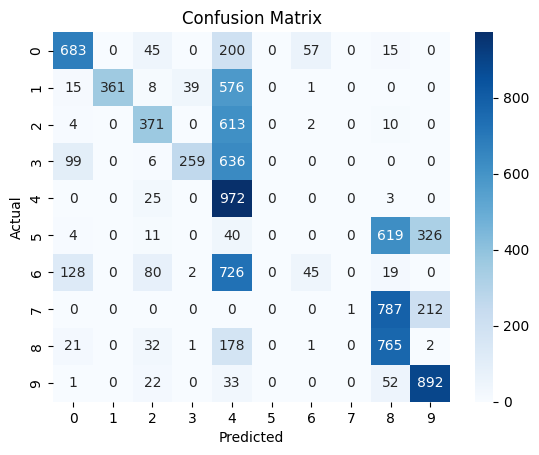

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(classification_report(y_pred_np , y_test_np))

              precision    recall  f1-score   support

         0.0       0.68      0.72      0.70       955
         1.0       0.36      1.00      0.53       361
         2.0       0.37      0.62      0.46       600
         3.0       0.26      0.86      0.40       301
         4.0       0.97      0.24      0.39      3974
         5.0       0.00      0.00      0.00         0
         6.0       0.04      0.42      0.08       106
         7.0       0.00      1.00      0.00         1
         8.0       0.77      0.34      0.47      2270
         9.0       0.89      0.62      0.73      1432

    accuracy                           0.43     10000
   macro avg       0.43      0.58      0.38     10000
weighted avg       0.80      0.43      0.49     10000



d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MCAEnv\AribaVenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
from sklearn.preprocessing import label_binarize

In [27]:
y_test_bin = label_binarize(y_test_np , classes = [0,1,2,3,4,5,6,7,8,9])

In [28]:
model.eval()

with torch.no_grad():
    y_scores = torch.softmax(model(X_test_tensor), dim=1).numpy()
print(y_scores)

[[0.20591962 0.03866173 0.15502833 ... 0.02763361 0.08828766 0.04596173]
 [0.12166566 0.16477193 0.10655966 ... 0.03869777 0.06499155 0.06070748]
 [0.08879635 0.07391495 0.16330591 ... 0.05698026 0.09513925 0.07913373]
 ...
 [0.07449984 0.03567216 0.13540311 ... 0.04049768 0.25357622 0.07215928]
 [0.08719917 0.02909205 0.21044415 ... 0.02435827 0.14164665 0.06832129]
 [0.09739346 0.03480182 0.22077158 ... 0.0210327  0.0737922  0.03969487]]


In [29]:
from sklearn.metrics import roc_curve , auc

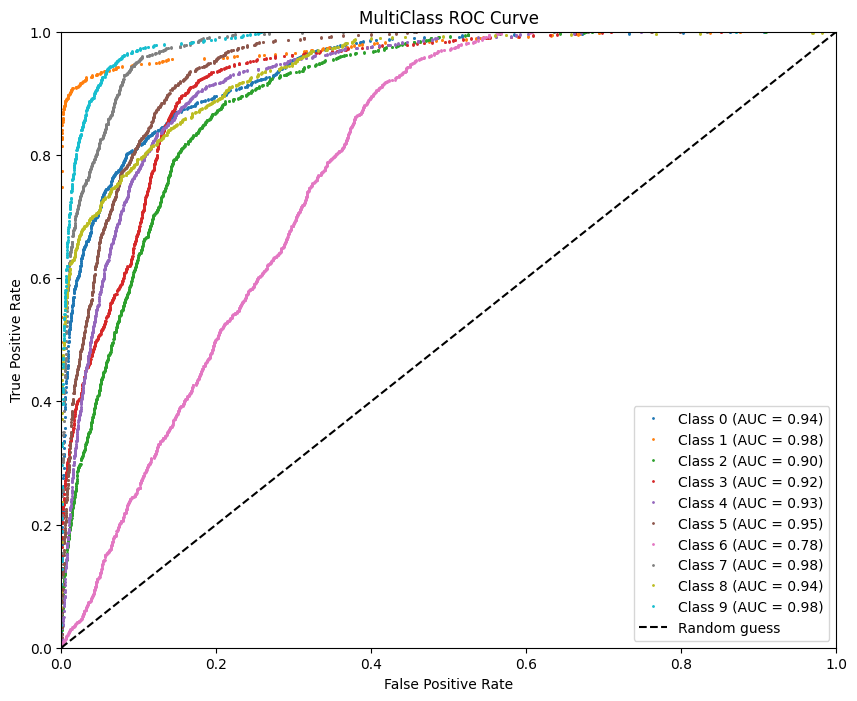

In [31]:
n_classes=y_test_bin.shape[1]
plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr,_ =roc_curve(y_test_bin[:,i] , y_scores[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,marker ='.',linestyle='None',markersize=2, label=f'Class {i} (AUC = { roc_auc:.2f})')
plt.plot([0,1] ,[0,1] , 'k--' , label ='Random guess')
plt.xlim([0.0 , 1.0])
plt.ylim([0.0 , 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MultiClass ROC Curve')
plt.legend(loc = 'lower right')
plt.show()

In [31]:
import torch